In [1]:
!pip install folium --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import heapq
import folium
from folium import plugins
import os

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [2]:
GRID_N = 40             # 40 x 40 grid
CELL_SIZE_M = 250        # each cell = 250 m  -> total area = 10km x 10km

def generate_terrain(n):
    x = np.linspace(0, 5, n)
    y = np.linspace(0, 5, n)
    X, Y = np.meshgrid(x, y)
    elevation = (
        150*np.sin(X) * np.cos(Y) +
        80*np.sin(2.1*X + 0.5) +
        60*np.cos(1.7*Y + 1.2) +
        200
    )
    elevation += np.random.normal(0, 5, elevation.shape)
    return elevation

def generate_wind_field(n, seed=1, base_speed=8.0, base_dir=45.0):
    rng = np.random.default_rng(seed)
    speed = base_speed + rng.normal(0, 1.2, (n, n))
    direction = base_dir + rng.normal(0, 8, (n, n))
    speed = np.clip(speed, 1, 20)
    return speed, direction

terrain = generate_terrain(GRID_N)
wind_speed, wind_dir = generate_wind_field(GRID_N)

# No-fly / obstacle zones (grid coordinates + radius in cells)
obstacles = [
    {"cx": 12, "cy": 20, "r": 3},
    {"cx": 28, "cy": 8,  "r": 2.5},
]

# Mission start (drone launch) and target drop zone, in grid coordinates
start_cell  = (2, 2)
target_cell = (32, 30)

os.makedirs("/content/data", exist_ok=True)

# Save dataset as CSV files (long format, easy to inspect / reuse)
xs, ys = np.meshgrid(range(GRID_N), range(GRID_N))
terrain_df = pd.DataFrame({
    "cell_x": xs.ravel(), "cell_y": ys.ravel(),
    "elevation_m": terrain.ravel()
})
wind_df = pd.DataFrame({
    "cell_x": xs.ravel(), "cell_y": ys.ravel(),
    "wind_speed_ms": wind_speed.ravel(),
    "wind_dir_deg_from_north": wind_dir.ravel()
})
obstacles_df = pd.DataFrame(obstacles)
mission_df = pd.DataFrame({
    "point": ["start", "target"],
    "cell_x": [start_cell[0], target_cell[0]],
    "cell_y": [start_cell[1], target_cell[1]],
})

terrain_df.to_csv("/content/data/terrain_grid.csv", index=False)
wind_df.to_csv("/content/data/wind_field.csv", index=False)
obstacles_df.to_csv("/content/data/obstacles.csv", index=False)
mission_df.to_csv("/content/data/mission_points.csv", index=False)

print("Dataset generated and saved to /content/data/")
print(" - terrain_grid.csv  :", terrain_df.shape)
print(" - wind_field.csv    :", wind_df.shape)
print(" - obstacles.csv     :", obstacles_df.shape)
print(" - mission_points.csv:", mission_df.shape)
terrain_df.head()

Dataset generated and saved to /content/data/
 - terrain_grid.csv  : (1600, 3)
 - wind_field.csv    : (1600, 4)
 - obstacles.csv     : (2, 3)
 - mission_points.csv: (2, 3)


,cell_x,cell_y,elevation_m
0,0,0,262.579079
1,1,0,295.874899
2,2,0,331.951332
3,3,0,362.883999
4,4,0,374.164730


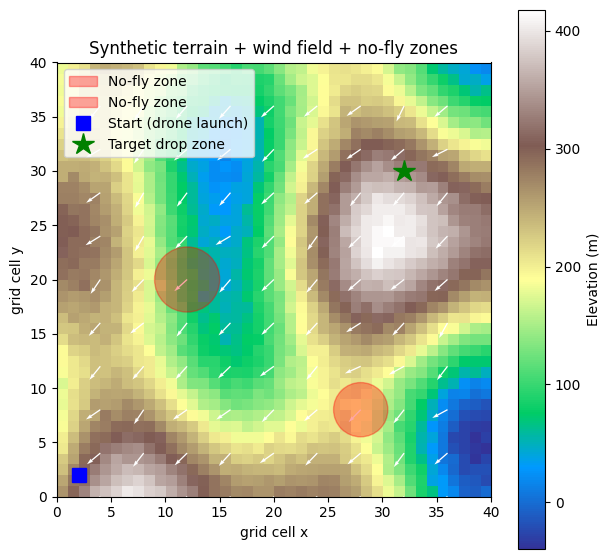

In [3]:
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(terrain, origin="lower", cmap="terrain",
               extent=[0, GRID_N, 0, GRID_N])
plt.colorbar(im, ax=ax, label="Elevation (m)")

# Wind quiver (subsample so arrows are readable)
step = 4
X, Y = np.meshgrid(range(GRID_N), range(GRID_N))
theta = np.deg2rad(wind_dir + 180)   # convert "from" direction to "blowing towards"
U = np.sin(theta)
V = np.cos(theta)
ax.quiver(X[::step, ::step], Y[::step, ::step],
          U[::step, ::step], V[::step, ::step],
          color="white", scale=25, width=0.003)

for ob in obstacles:
    circ = plt.Circle((ob["cx"], ob["cy"]), ob["r"], color="red", alpha=0.35, label="No-fly zone")
    ax.add_patch(circ)

ax.plot(*start_cell, "bs", markersize=10, label="Start (drone launch)")
ax.plot(*target_cell, "g*", markersize=16, label="Target drop zone")
ax.set_title("Synthetic terrain + wind field + no-fly zones")
ax.set_xlabel("grid cell x"); ax.set_ylabel("grid cell y")
ax.legend(loc="upper left")
plt.show()

In [4]:
class Environment:
    def __init__(self, terrain, wind_speed, wind_dir, cell_size_m):
        self.terrain = terrain
        self.wind_speed = wind_speed
        self.wind_dir = wind_dir
        self.cell_size_m = cell_size_m
        self.n = terrain.shape[0]

    def elevation_at(self, cx, cy):
        cx = int(np.clip(round(cx), 0, self.n-1))
        cy = int(np.clip(round(cy), 0, self.n-1))
        return self.terrain[cy, cx]

    def wind_at(self, cx, cy):
        cx = int(np.clip(round(cx), 0, self.n-1))
        cy = int(np.clip(round(cy), 0, self.n-1))
        return self.wind_speed[cy, cx], self.wind_dir[cy, cx]

    def to_meters(self, cx, cy):
        return np.array([cx * self.cell_size_m, cy * self.cell_size_m])

env = Environment(terrain, wind_speed, wind_dir, CELL_SIZE_M)
print("Sensor check at target cell -> elevation:", round(env.elevation_at(*target_cell), 1),
      "m | wind:", [round(v,2) for v in env.wind_at(*target_cell)])

Sensor check at target cell -> elevation: 324.5 m | wind: [np.float64(8.42), np.float64(57.74)]


In [5]:
class Drone:
    def __init__(self, position_cell, altitude_m, env):
        self.position = np.array(position_cell, dtype=float)  # (cell_x, cell_y)
        self.altitude = altitude_m
        self.env = env
        self.log = [self.position.copy()]

    def gps(self):
        """Simulated noisy GPS reading."""
        noise = np.random.normal(0, 0.05, 2)   # small GPS jitter, in grid cells
        return self.position + noise

    def move_to(self, cell):
        self.position = np.array(cell, dtype=float)
        self.log.append(self.position.copy())

    def sense_wind(self):
        return self.env.wind_at(*self.position)

drone = Drone(start_cell, altitude_m=600.0, env=env)
print("Drone initialized at", drone.position, "| GPS reading:", drone.gps())

Drone initialized at [2. 2.] | GPS reading: [1.99085518 2.06874382]


In [6]:
def in_obstacle(cx, cy, obstacles):
    for ob in obstacles:
        if (cx-ob["cx"])**2 + (cy-ob["cy"])**2 <= ob["r"]**2:
            return True
    return False

def astar(grid_n, start, goal, terrain, wind_speed, obstacles):
    def heuristic(a, b):
        return np.hypot(a[0]-b[0], a[1]-b[1])

    neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    open_set = [(0, start)]
    came_from = {}
    g_score = {start: 0}
    visited = set()

    while open_set:
        _, current = heapq.heappop(open_set)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path
        if current in visited:
            continue
        visited.add(current)

        for dx, dy in neighbors:
            nx, ny = current[0]+dx, current[1]+dy
            if not (0 <= nx < grid_n and 0 <= ny < grid_n):
                continue
            if in_obstacle(nx, ny, obstacles):
                continue
            step_cost = np.hypot(dx, dy)
            terrain_penalty = abs(terrain[ny, nx] - terrain[current[1], current[0]]) * 0.01
            wind_penalty = wind_speed[ny, nx] * 0.02
            cost = step_cost + terrain_penalty + wind_penalty
            tentative_g = g_score[current] + cost
            neighbor = (nx, ny)
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
                came_from[neighbor] = current
    return None

path = astar(GRID_N, start_cell, target_cell, terrain, wind_speed, obstacles)
print(f"Path found with {len(path)} waypoints (grid cells).")
print("First waypoints:", path[:5])
print("Last waypoints :", path[-5:])

# Move the simulated drone along the planned path
for cell in path:
    drone.move_to(cell)
print("Drone final position:", drone.position)

Path found with 31 waypoints (grid cells).
First waypoints: [(2, 2), (3, 3), (4, 4), (5, 5), (6, 6)]
Last waypoints : [(28, 28), (29, 28), (30, 29), (31, 30), (32, 30)]
Drone final position: [32. 30.]


In [7]:
DROP_ALTITUDE_M   = 600.0   # release altitude AGL (Above Ground Level)
DESCENT_RATE_MS   = 5.5     # m/s vertical descent rate of the guided parafoil
GLIDE_RATIO       = 3.0     # forward glide distance per unit of fall (guided parafoil L/D)

def wind_to_vector(speed, direction_deg):
    """Meteorological direction = direction the wind is COMING FROM.
    Convert to an (east, north) vector describing where the wind BLOWS TOWARDS."""
    theta = np.deg2rad(direction_deg + 180)
    vx = speed * np.sin(theta)
    vy = speed * np.cos(theta)
    return np.array([vx, vy])

def compute_carp(target_xy, altitude_m, descent_rate, wind_vec):
    time_of_fall = altitude_m / descent_rate
    drift = wind_vec * time_of_fall
    carp_xy = target_xy - drift
    return carp_xy, time_of_fall, drift

target_xy_m = env.to_meters(*target_cell)
wind_speed_here, wind_dir_here = env.wind_at(*target_cell)
wind_vec = wind_to_vector(wind_speed_here, wind_dir_here)

carp_xy, time_of_fall, drift = compute_carp(target_xy_m, DROP_ALTITUDE_M, DESCENT_RATE_MS, wind_vec)

print(f"Wind at target: {wind_speed_here:.2f} m/s from {wind_dir_here:.1f} deg")
print(f"Time of fall  : {time_of_fall:.1f} s")
print(f"Expected drift: {drift} m")
print(f"Target (m)    : {target_xy_m}")
print(f"CARP (m)      : {carp_xy}  <-- release the payload here")

Wind at target: 8.42 m/s from 57.7 deg
Time of fall  : 109.1 s
Expected drift: [-776.75587089 -490.33675319] m
Target (m)    : [8000 7500]
CARP (m)      : [8776.75587089 7990.33675319]  <-- release the payload here


In [8]:
def simulate_descent(release_xy, target_xy, altitude, descent_rate, wind_vec,
                      glide_ratio, dt=0.5, guidance_gain=0.4):
    pos = np.array(release_xy, dtype=float)
    alt = altitude
    trail = [pos.copy()]
    max_horizontal_speed = descent_rate * glide_ratio

    while alt > 0:
        to_target = target_xy - pos
        dist = np.linalg.norm(to_target)
        desired_dir = to_target / dist if dist > 1e-6 else np.zeros(2)
        control_vec = desired_dir * max_horizontal_speed * guidance_gain
        velocity = wind_vec + control_vec
        pos = pos + velocity * dt
        alt -= descent_rate * dt
        trail.append(pos.copy())
    return np.array(trail)

trail = simulate_descent(carp_xy, target_xy_m, DROP_ALTITUDE_M, DESCENT_RATE_MS,
                          wind_vec, GLIDE_RATIO)
landing_point = trail[-1]
miss_distance = np.linalg.norm(landing_point - target_xy_m)

print(f"Landing point : {landing_point}")
print(f"Target        : {target_xy_m}")
print(f"Miss distance : {miss_distance:.1f} m  (typical real JPADS CEP is ~50-150 m)")

Landing point : [7921.74333732 7450.59951352]
Target        : [8000 7500]
Miss distance : 92.5 m  (typical real JPADS CEP is ~50-150 m)


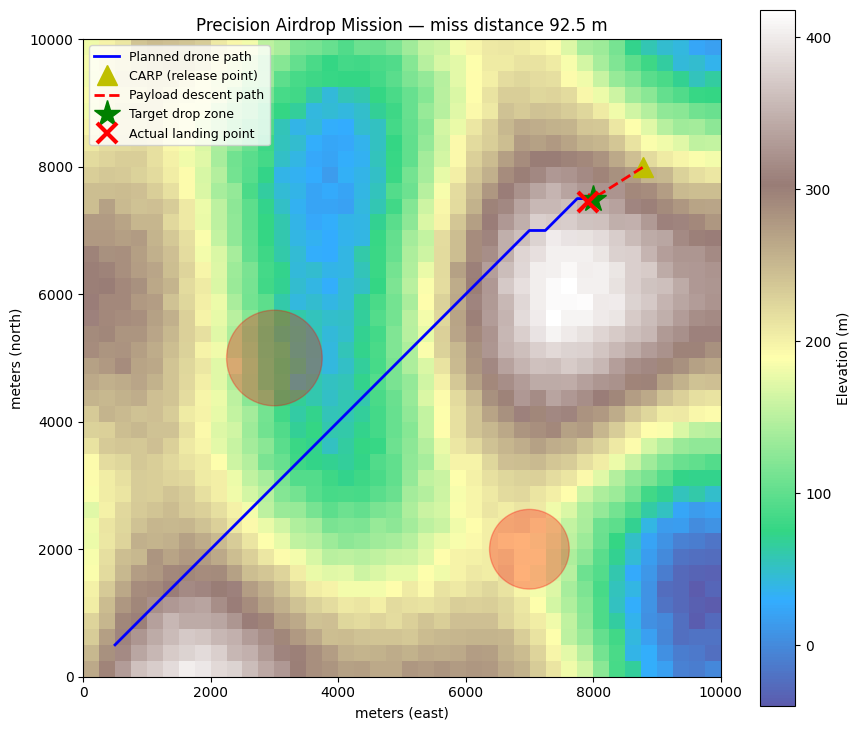

In [9]:
fig, ax = plt.subplots(figsize=(9,9))
extent_m = [0, GRID_N*CELL_SIZE_M, 0, GRID_N*CELL_SIZE_M]
im = ax.imshow(terrain, origin="lower", cmap="terrain", extent=extent_m, alpha=0.8)
plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)

path_xy = np.array([env.to_meters(*p) for p in path])
ax.plot(path_xy[:,0], path_xy[:,1], "b-", linewidth=2, label="Planned drone path")

ax.plot(*carp_xy, "y^", markersize=14, label="CARP (release point)")
ax.plot(trail[:,0], trail[:,1], "r--", linewidth=2, label="Payload descent path")
ax.plot(*target_xy_m, "g*", markersize=20, label="Target drop zone")
ax.plot(*landing_point, "rx", markersize=14, markeredgewidth=3, label="Actual landing point")

miss_circle = plt.Circle(target_xy_m, miss_distance, fill=False,
                          color="red", linestyle=":", linewidth=1.5)
ax.add_patch(miss_circle)

for ob in obstacles:
    circ = plt.Circle((ob["cx"]*CELL_SIZE_M, ob["cy"]*CELL_SIZE_M),
                       ob["r"]*CELL_SIZE_M, color="red", alpha=0.3)
    ax.add_patch(circ)

ax.set_title(f"Precision Airdrop Mission — miss distance {miss_distance:.1f} m")
ax.set_xlabel("meters (east)"); ax.set_ylabel("meters (north)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
CENTER_LAT, CENTER_LON = 16.5062, 80.6480   # example center (Vijayawada, India) - change as needed

def meters_to_latlon(x_m, y_m, center_lat, center_lon):
    # simple equirectangular approximation, fine for a 10km x 10km area
    d_lat = (y_m - GRID_N*CELL_SIZE_M/2) / 111_320
    d_lon = (x_m - GRID_N*CELL_SIZE_M/2) / (111_320 * np.cos(np.deg2rad(center_lat)))
    return center_lat + d_lat, center_lon + d_lon

m = folium.Map(location=[CENTER_LAT, CENTER_LON], zoom_start=13, tiles="OpenStreetMap")

# Drone planned path
path_latlon = [meters_to_latlon(x, y, CENTER_LAT, CENTER_LON) for x, y in path_xy]
folium.PolyLine(path_latlon, color="blue", weight=4, opacity=0.8,
                 tooltip="Planned drone path").add_to(m)

# Payload descent path
trail_latlon = [meters_to_latlon(x, y, CENTER_LAT, CENTER_LON) for x, y in trail]
folium.PolyLine(trail_latlon, color="red", weight=3, opacity=0.8, dash_array="5,5",
                 tooltip="Payload descent path").add_to(m)

carp_latlon = meters_to_latlon(*carp_xy, CENTER_LAT, CENTER_LON)
folium.Marker(carp_latlon, icon=folium.Icon(color="orange", icon="plane", prefix="fa"),
              tooltip="CARP - release point").add_to(m)

target_latlon = meters_to_latlon(*target_xy_m, CENTER_LAT, CENTER_LON)
folium.Marker(target_latlon, icon=folium.Icon(color="green", icon="flag", prefix="fa"),
              tooltip="Target drop zone").add_to(m)

landing_latlon = meters_to_latlon(*landing_point, CENTER_LAT, CENTER_LON)
folium.Marker(landing_latlon, icon=folium.Icon(color="red", icon="times", prefix="fa"),
              tooltip=f"Actual landing (miss {miss_distance:.1f} m)").add_to(m)

for ob in obstacles:
    ob_latlon = meters_to_latlon(ob["cx"]*CELL_SIZE_M, ob["cy"]*CELL_SIZE_M, CENTER_LAT, CENTER_LON)
    folium.Circle(ob_latlon, radius=ob["r"]*CELL_SIZE_M, color="red", fill=True,
                   fill_opacity=0.2, tooltip="No-fly zone").add_to(m)

m

In [11]:
summary = pd.DataFrame({
    "metric": [
        "Path waypoints (grid cells)",
        "Drop altitude (m)",
        "Descent rate (m/s)",
        "Time of fall (s)",
        "Wind speed at target (m/s)",
        "Wind direction (deg from north)",
        "Wind drift magnitude (m)",
        "Miss distance (m)",
    ],
    "value": [
        len(path),
        DROP_ALTITUDE_M,
        DESCENT_RATE_MS,
        round(time_of_fall, 1),
        round(wind_speed_here, 2),
        round(wind_dir_here, 1),
        round(np.linalg.norm(drift), 1),
        round(miss_distance, 1),
    ]
})
summary

,metric,value
0,Path waypoints (grid cells),31.00
1,Drop altitude (m),600.00
2,Descent rate (m/s),5.50
3,Time of fall (s),109.10
4,Wind speed at target (m/s),8.42
5,Wind direction (deg from north),57.70
6,Wind drift magnitude (m),918.60
7,Miss distance (m),92.50
